# Question 2: Callaway-Sant'Anna Difference-in-Differences (CSDiD)
 
**Dataset**: Bacon (2021) Example Data — State-level mortality and policy adoption

---

## Overview

This notebook implements the Callaway and Sant'Anna (2021) estimator to address limitations of TWFE in staggered adoption settings.

**Structure:**
- **Part a)** Estimate ATT(g,t) — group-time average treatment effects
- **Part b)** Compute aggregations: by group, by period, by event-time
- **Part c)** Explain the meaning of each aggregation
- **Part d)** Compare CSDiD results with TWFE event-study from Q1

**Key Advantage of CSDiD:** Unlike TWFE, CSDiD:
- Uses only **clean comparisons** (never-treated or not-yet-treated units as controls)
- Allows for **heterogeneous treatment effects** across cohorts and over time
- Produces **unbiased estimates** under weaker assumptions than TWFE

In [33]:
# =============================================================================
# SETUP: Load Required Libraries
# =============================================================================
library(tidyverse)
library(did)
library(fixest)
library(broom)
library(scales)

theme_set(theme_minimal(base_size = 14))
cat("Libraries loaded successfully!\n")

Libraries loaded successfully!


In [34]:
# =============================================================================
# DATA LOADING
# =============================================================================
url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df <- read.csv(url)

# Normalize column names
if ('_nfd' %in% names(df)) df <- df %>% rename(X_nfd = `_nfd`)

cat("Dataset loaded:", nrow(df), "rows x", ncol(df), "columns\n")
cat("\nTreatment cohorts (X_nfd = 0 means never-treated):\n")
print(table(df$X_nfd))

Dataset loaded: 1617 rows x 10 columns

Treatment cohorts (X_nfd = 0 means never-treated):

1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985 
  66   66  231   99  330   99   66   33   99   33   33   33 

Treatment cohorts (X_nfd = 0 means never-treated):

1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985 
  66   66  231   99  330   99   66   33   99   33   33   33 


---

## Part a) Estimate ATT(g,t) using CSDiD (3 points)

### The Callaway-Sant'Anna Estimator

The CSDiD estimator computes **group-time average treatment effects**:

$$ATT(g,t) = E[Y_t(1) - Y_t(0) \mid G_g = 1]$$

Where:
- $g$ = treatment cohort (first treatment period)
- $t$ = calendar time period
- $G_g = 1$ indicates units first treated in period $g$

### Control Group Choice

We use `control_group = "notyettreated"` which includes:
1. **Never-treated units**: Units that never receive treatment (X_nfd = 0)
2. **Not-yet-treated units**: Units treated in the future but not yet at time $t$

**Why this choice?**
- Avoids "forbidden comparisons" using already-treated units as controls
- Increases sample size for comparison group, improving precision
- Following Callaway & Sant'Anna (2021), this provides valid identification under staggered adoption
- Unlike TWFE, we never use treated units' post-treatment outcomes as counterfactuals

**Controls included:** `pcinc`, `asmrh`, `cases` — same controls as in the TWFE model for comparability.

In [35]:
# =============================================================================
# ESTIMATE ATT(g,t) USING CALLAWAY-SANT'ANNA
# =============================================================================
# Using doubly-robust estimation with covariates

att_gt_obj <- tryCatch({
  att_gt(
    yname = "asmrs",          # Outcome variable
    tname = "year",           # Time variable
    idname = "stfips",        # Unit identifier
    gname = "X_nfd",          # Group (first treatment period, 0 = never-treated)
    xformla = ~ pcinc + asmrh + cases,  # Control variables
    data = df,
    control_group = "notyettreated",    # Use not-yet-treated as controls
    est_method = "dr",        # Doubly robust estimation
    anticipation = 0,         # No anticipation
    base_period = "varying"   # Varying base period
  )
}, error = function(e) {
  cat("Note: Estimation with covariates failed. Falling back to no covariates.\n")
  att_gt(
    yname = "asmrs", tname = "year", idname = "stfips", gname = "X_nfd",
    xformla = ~ 1, data = df, control_group = "notyettreated",
    est_method = "dr", anticipation = 0, base_period = "varying"
  )
})

cat("========================================================================\n")
cat("ATT(g,t) ESTIMATION COMPLETE\n")
cat("Control Group: Not-yet-treated (never-treated + future-treated)\n")
cat("Estimation Method: Doubly Robust\n")
cat("========================================================================\n")
summary(att_gt_obj)

Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"dropped 429 rows from original data due to missing data"
Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"Be aware that there are some small groups in your dataset.
  Check groups: 1969,1970,1971,1972,1974,1975,1976,1977,1980,1984,1985."
Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"Be aware that there are some small groups in your dataset.
  Check groups: 1969,1970,1971,1972,1974,1975,1976,1977,1980,1984,1985."
Warning message in compute.att_gt(dp):
"overlap condition violated for 1969 in time period 1977"
Warning message in compute.att_gt(dp):
"Not enough control units for group 1969 in time period 1977 to run specified regression"
Warning message in compute.att_gt(dp):
"overlap condition violated for 1969 in time period 1978"
Warning message in compute.att_gt(dp):
"Not enough control units for group 1969 in time period 1978 t

Note: Estimation with covariates failed. Falling back to no covariates.


Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"dropped 429 rows from original data due to missing data"
Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"Be aware that there are some small groups in your dataset.
  Check groups: 1969,1970,1972,1974,1975,1976,1977,1980,1984,1985."
Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"Be aware that there are some small groups in your dataset.
  Check groups: 1969,1970,1972,1974,1975,1976,1977,1980,1984,1985."
Warning message in att_gt(yname = "asmrs", tname = "year", idname = "stfips", gname = "X_nfd", :
"Not returning pre-test Wald statistic due to singular covariance matrix"
Warning message in att_gt(yname = "asmrs", tname = "year", idname = "stfips", gname = "X_nfd", :
"Not returning pre-test Wald statistic due to singular covariance matrix"
Warning message in att_gt(yname = "asmrs", tname = "year", idname = "stfips", gname = "X_nfd

ATT(g,t) ESTIMATION COMPLETE
Control Group: Not-yet-treated (never-treated + future-treated)
Estimation Method: Doubly Robust

Call:
att_gt(yname = "asmrs", tname = "year", idname = "stfips", gname = "X_nfd", 
    xformla = ~1, data = df, control_group = "notyettreated", 
    anticipation = 0, est_method = "dr", base_period = "varying")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
  1969 1965  -3.8814     6.0149     -153.2058    145.4430  
  1969 1966   5.5588     8.9977     -217.8150    228.9326  
  1969 1967   2.0449     5.4006     -132.0284    136.1181  
  1969 1968   3.0803     2.8358      -67.3195     73.4801  
  1969 1969   0.8709     5.8025     -143.1801    144.9218  
  1

In [36]:
# Create clean ATT(g,t) results table
att_gt_df <- data.frame(
  group = att_gt_obj$group,
  time = att_gt_obj$t,
  att = att_gt_obj$att,
  se = att_gt_obj$se,
  ci_lower = att_gt_obj$att - 1.96 * att_gt_obj$se,
  ci_upper = att_gt_obj$att + 1.96 * att_gt_obj$se
)

cat("========================================================================\n")
cat("ATT(g,t) RESULTS TABLE (First 20 rows)\n")
cat("========================================================================\n")
print(head(att_gt_df, 20))

cat(sprintf("\nTotal (g,t) cells: %d\n", nrow(att_gt_df)))

# Save results
write.csv(att_gt_df, "../output/att_gt_results.csv", row.names = FALSE)

ATT(g,t) RESULTS TABLE (First 20 rows)
ATT(g,t) RESULTS TABLE (First 20 rows)
   group time          att       se   ci_lower   ci_upper
1   1969 1965  -3.88136207 6.014912 -15.670589  7.9078652
2   1969 1966   5.55878432 8.997685 -12.076679 23.1942473
3   1969 1967   2.04487733 5.400583  -8.540265 12.6300195
4   1969 1968   3.08031811 2.835764  -2.477779  8.6384148
5   1969 1969   0.87086184 5.802492 -10.502022 12.2437454
6   1969 1970  -9.57458782 8.318138 -25.878138  6.7289626
7   1969 1971 -12.38278687 7.177474 -26.450635  1.6850612
8   1969 1972  -4.23193585 4.101097 -12.270086  3.8062140
9   1969 1973   4.46408447 8.034056 -11.282664 20.2108333
10  1969 1974   0.01875305 6.168293 -12.071102 12.1086080
11  1969 1975   0.86218779 5.255667  -9.438920 11.1632952
12  1969 1976 -13.26973979 8.050274 -29.048277  2.5087975
13  1969 1977  -0.05026372 6.314637 -12.426953 12.3264254
14  1969 1978  -5.36576207 8.960187 -22.927729 12.1962045
15  1969 1979  -2.04050128 1.202884  -4.398154  0.31

### Interpretation of ATT(g,t)

**What is ATT(g,t)?**  
The group-time average treatment effect $ATT(g,t)$ represents the average effect of treatment on outcome for units first treated in period $g$, measured at calendar time $t$.

For example:
- $ATT(1970, 1975)$ = average treatment effect for the 1970 cohort, measured in 1975 (5 years after treatment)
- $ATT(1975, 1975)$ = average treatment effect for the 1975 cohort at the moment of treatment (impact effect)

**Why not-yet-treated controls?**  
Using not-yet-treated units ensures we never compare treated outcomes to other treated outcomes. This addresses the core concern raised by Goodman-Bacon (2021) about TWFE — that already-treated units are implicitly used as controls, biasing estimates when treatment effects are heterogeneous.

---

## Part b) Aggregations (3 points)

CSDiD provides three aggregation methods to summarize the many ATT(g,t) estimates.

### b.1) Aggregation by Group (Treatment Cohort)

In [37]:
# Aggregation by Group
agg_group <- aggte(att_gt_obj, type = "group")

cat("========================================================================\n")
cat("AGGREGATION BY GROUP (Treatment Cohort)\n")
cat("========================================================================\n")
summary(agg_group)

Warning message in compute.aggte(MP = MP, type = type, balance_e = balance_e, min_e = min_e, :
"Simultaneous critical value is arguably `too large' to be realible. This usually happens when number of observations per group is small and/or there is no much variation in outcomes."


AGGREGATION BY GROUP (Treatment Cohort)
AGGREGATION BY GROUP (Treatment Cohort)

Call:
aggte(MP = att_gt_obj, type = "group")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on group/cohort aggregation:  
    ATT    Std. Error     [ 95%  Conf. Int.] 
 1.3553        3.8414    -6.1738      8.8843 


Group Effects:
 Group Estimate Std. Error [95% Simult.   Conf. Band] 
  1969  -3.2769     6.0949 -2.337342e+16 2.337342e+16 
  1970 -17.0455     9.2119 -3.532707e+16 3.532707e+16 
  1971   1.6685     4.6195 -1.771560e+16 1.771560e+16 
  1972   2.7390     6.5828 -2.524481e+16 2.524481e+16 
  1973  11.8298     5.8738 -2.252553e+16 2.252553e+16 
  1974  -6.8765     3.7499 -1.438078e+16 1.438078e+16 
  1975  -3.4593     3.2741 -1.255599e+16 1.255599e+16 
  

In [38]:
# Extract group-level results
group_df <- data.frame(
  group = agg_group$egt,
  att = agg_group$att.egt,
  se = agg_group$se.egt
) %>% mutate(ci_lower = att - 1.96 * se, ci_upper = att + 1.96 * se)

cat("Group-Level ATT Estimates:\n")
print(group_df)
cat(sprintf("\n*** Overall ATT: %.4f (SE: %.4f) ***\n", agg_group$overall.att, agg_group$overall.se))

write.csv(group_df, "../output/group_aggregation.csv", row.names = FALSE)

Group-Level ATT Estimates:
   group        att        se   ci_lower   ci_upper
1   1969  -3.276924  6.094853 -15.222835  8.6689874
2   1970 -17.045527  9.211885 -35.100821  1.0097665
3   1971   1.668459  4.619518  -7.385797 10.7227146
4   1972   2.738983  6.582835 -10.163374 15.6413406
5   1973  11.829834  5.873756   0.317272 23.3423963
6   1974  -6.876458  3.749931 -14.226322  0.4734065
7   1975  -3.459287  3.274099  -9.876520  2.9579467
8   1976  -2.430675  1.522997  -5.415748  0.5543991
9   1977  -4.666900 33.022372 -69.390749 60.0569501
10  1980  -8.656535  3.018202 -14.572211 -2.7408592
11  1984   2.520073        NA         NA         NA

*** Overall ATT: 1.3553 (SE: 3.8414) ***
   group        att        se   ci_lower   ci_upper
1   1969  -3.276924  6.094853 -15.222835  8.6689874
2   1970 -17.045527  9.211885 -35.100821  1.0097665
3   1971   1.668459  4.619518  -7.385797 10.7227146
4   1972   2.738983  6.582835 -10.163374 15.6413406
5   1973  11.829834  5.873756   0.317272 23.342

### b.2) Aggregation by Period (Calendar Time)

In [39]:
# Aggregation by Calendar Time
agg_calendar <- aggte(att_gt_obj, type = "calendar")

cat("========================================================================\n")
cat("AGGREGATION BY CALENDAR TIME\n")
cat("========================================================================\n")
summary(agg_calendar)

AGGREGATION BY CALENDAR TIME

Call:
aggte(MP = att_gt_obj, type = "calendar")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on calendar time aggregation:  
    ATT    Std. Error     [ 95%  Conf. Int.] 
 0.5594         2.837     -5.001      6.1197 


Time Effects:
 Time Estimate Std. Error [95% Simult.  Conf. Band] 
 1969   0.8709     6.5795      -15.6428     17.3845 
 1970  -4.9186     6.0589      -20.1257     10.2885 
 1971  -7.4450     4.5192      -18.7876      3.8976 
 1972  -7.1945     4.4559      -18.3783      3.9893 
 1973   4.5117     4.2767       -6.2223     15.2457 
 1974   4.7292     4.8380       -7.4136     16.8720 
 1975   8.6461     4.6702       -3.0755     20.3678 
 1976   3.1583     9.0063      -19.4462     25.7629 
 1977   6.751

In [40]:
# Extract calendar-time results
calendar_df <- data.frame(
  year = agg_calendar$egt,
  att = agg_calendar$att.egt,
  se = agg_calendar$se.egt
) %>% mutate(ci_lower = att - 1.96 * se, ci_upper = att + 1.96 * se)

cat("Calendar-Time ATT Estimates:\n")
print(calendar_df)

write.csv(calendar_df, "../output/calendar_aggregation.csv", row.names = FALSE)

Calendar-Time ATT Estimates:
   year        att       se    ci_lower   ci_upper
1  1969  0.8708618 6.579485 -12.0249291 13.7666527
2  1970 -4.9186387 6.058911 -16.7941050  6.9568275
3  1971 -7.4449726 4.519191 -16.3025861  1.4126409
4  1972 -7.1945010 4.455926 -15.9281161  1.5391142
5  1973  4.5116921 4.276718  -3.8706750 12.8940592
6  1974  4.7291866 4.838018  -4.7533284 14.2117016
7  1975  8.6461465 4.670232  -0.5075082 17.7998011
8  1976  3.1583291 9.006252 -14.4939255 20.8105837
9  1977  6.7518090 6.352807  -5.6996925 19.2033105
10 1978 -2.7159050 3.340905  -9.2640793  3.8322693
11 1979  1.8886907 5.348568  -8.5945021 12.3718834
12 1980 -1.0344283 3.139475  -7.1877989  5.1189423
13 1981  4.4693855 6.292072  -7.8630752 16.8018462
14 1982 -5.1739713 3.001330 -11.0565784  0.7086358
15 1983 -1.4180145 5.625709 -12.4444048  9.6083758
16 1984  3.8242876 3.449435  -2.9366046 10.5851799
   year        att       se    ci_lower   ci_upper
1  1969  0.8708618 6.579485 -12.0249291 13.7666527
2 

### b.3) Aggregation by Event-Time (Dynamic Effects)

In [41]:
# Aggregation by Event Time (Dynamic Effects)
agg_event <- aggte(att_gt_obj, type = "dynamic")

cat("========================================================================\n")
cat("AGGREGATION BY EVENT-TIME (Dynamic Effects)\n")
cat("========================================================================\n")
summary(agg_event)

AGGREGATION BY EVENT-TIME (Dynamic Effects)

Call:
aggte(MP = att_gt_obj, type = "dynamic")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on event-study/dynamic aggregation:  
    ATT    Std. Error     [ 95%  Conf. Int.] 
 0.1073        3.5647    -6.8794       7.094 


Dynamic Effects:
 Event time Estimate Std. Error [95% Simult.  Conf. Band] 
        -19   1.9132     1.9150       -3.3161      7.1424 
        -18   0.2689     2.1384       -5.5703      6.1081 
        -17  -2.7782     2.4652       -9.5096      3.9532 
        -16  -2.3641     2.2091       -8.3963      3.6682 
        -15  -2.6024     3.0466      -10.9214      5.7166 
        -14   1.6679     1.6354       -2.7978      6.1337 
        -13  -5.7314     4.7751      -18.7704      7.3

In [42]:
# Extract event-time results
event_df <- data.frame(
  event_time = agg_event$egt,
  att = agg_event$att.egt,
  se = agg_event$se.egt
) %>% 
  mutate(ci_lower = att - 1.96 * se, ci_upper = att + 1.96 * se) %>%
  arrange(event_time)

cat("Event-Time ATT Estimates:\n")
print(event_df)
cat(sprintf("\n*** Overall ATT: %.4f (SE: %.4f) ***\n", agg_event$overall.att, agg_event$overall.se))

write.csv(event_df, "../output/csdid_event_time.csv", row.names = FALSE)

Event-Time ATT Estimates:
   event_time         att        se    ci_lower  ci_upper
1         -19   1.9131519  1.915047  -1.8403401  5.666644
2         -18   0.2688974  2.138426  -3.9224180  4.460213
3         -17  -2.7781966  2.465151  -7.6098916  2.053498
4         -16  -2.3640792  2.209110  -6.6939353  1.965777
5         -15  -2.6023732  3.046561  -8.5736320  3.368886
6         -14   1.6679274  1.635438  -1.5375313  4.873386
7         -13  -5.7314185  4.775118 -15.0906500  3.627813
8         -12   6.1681238  7.008367  -7.5682747 19.904522
9         -11  -9.6671449  5.398088 -20.2473977  0.913108
10        -10   9.0972067  6.291112  -3.2333735 21.427787
11         -9  -7.4354999  4.707681 -16.6625552  1.791555
12         -8   3.3430454  2.784037  -2.1136662  8.799757
13         -7   0.3180943  2.164772  -3.9248588  4.561048
14         -6  -1.2394527  3.292902  -7.6935400  5.214635
15         -5  -2.1888093  2.233510  -6.5664890  2.188870
16         -4   3.3185045  1.801917  -0.213253

### Aggregation Visualizations

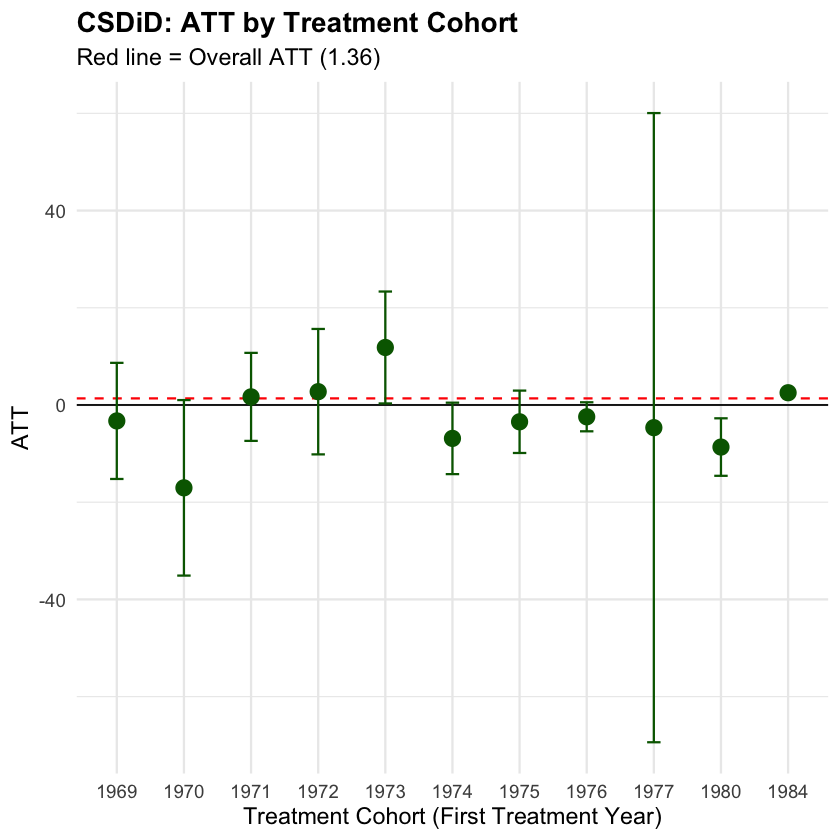

In [43]:
# Plot: Group Aggregation
p_group <- ggplot(group_df, aes(x = factor(group), y = att)) +
  geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
  geom_hline(yintercept = agg_group$overall.att, color = "red", linetype = "dashed") +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), width = 0.2, color = "darkgreen") +
  geom_point(color = "darkgreen", size = 4) +
  labs(title = "CSDiD: ATT by Treatment Cohort",
       subtitle = paste0("Red line = Overall ATT (", round(agg_group$overall.att, 2), ")"),
       x = "Treatment Cohort (First Treatment Year)", y = "ATT") +
  theme(plot.title = element_text(face = "bold"))

print(p_group)
ggsave("../output/csdid_group_agg.png", p_group, width = 10, height = 6, dpi = 300)

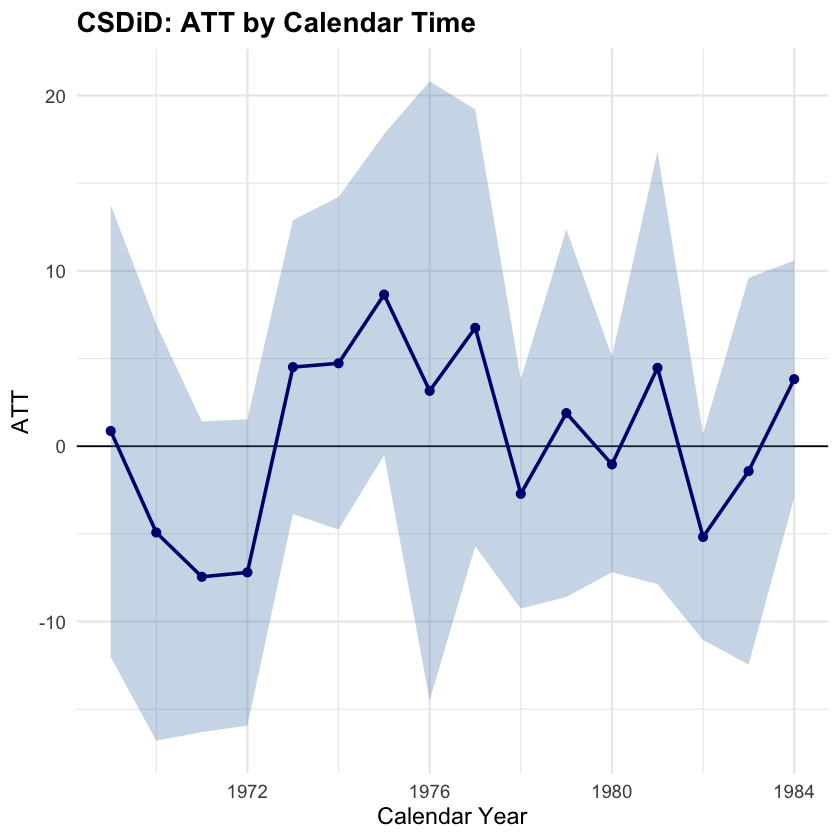

In [44]:
# Plot: Calendar Time Aggregation
p_calendar <- ggplot(calendar_df, aes(x = year, y = att)) +
  geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
  geom_ribbon(aes(ymin = ci_lower, ymax = ci_upper), fill = "steelblue", alpha = 0.3) +
  geom_line(color = "navy", linewidth = 1) +
  geom_point(color = "navy", size = 2) +
  labs(title = "CSDiD: ATT by Calendar Time",
       x = "Calendar Year", y = "ATT") +
  theme(plot.title = element_text(face = "bold"))

print(p_calendar)
ggsave("../output/csdid_calendar_agg.png", p_calendar, width = 10, height = 6, dpi = 300)

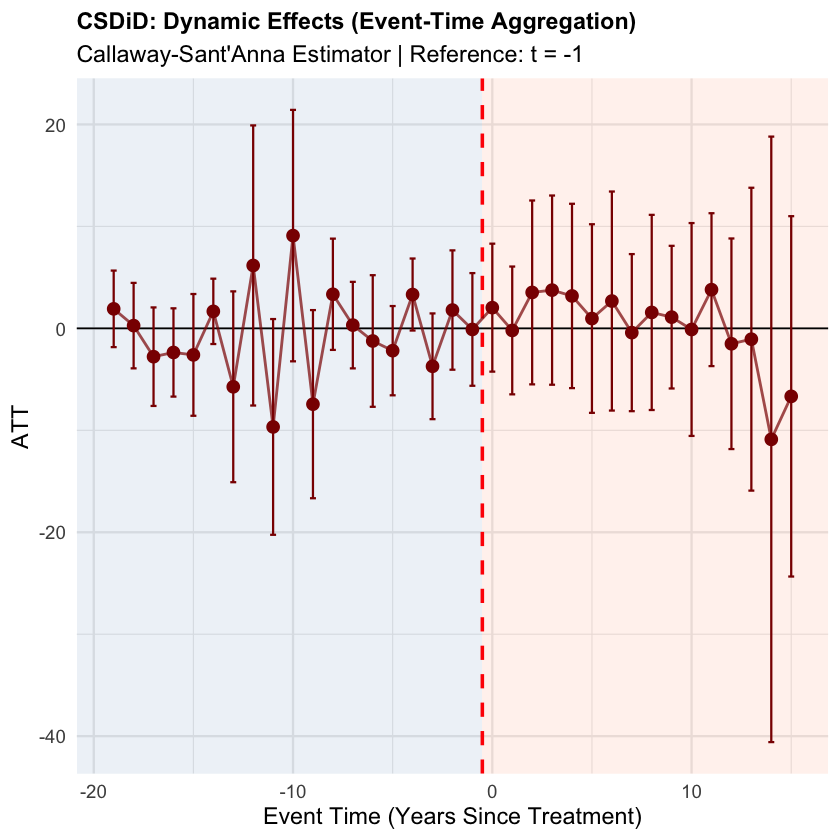

In [45]:
# Plot: Event-Time (Dynamic) Aggregation
p_event <- ggplot(event_df, aes(x = event_time, y = att)) +
  annotate("rect", xmin = -Inf, xmax = -0.5, ymin = -Inf, ymax = Inf, fill = "steelblue", alpha = 0.1) +
  annotate("rect", xmin = -0.5, xmax = Inf, ymin = -Inf, ymax = Inf, fill = "coral", alpha = 0.1) +
  geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
  geom_vline(xintercept = -0.5, color = "red", linetype = "dashed", linewidth = 1) +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), width = 0.3, color = "darkred") +
  geom_line(color = "darkred", alpha = 0.7, linewidth = 0.8) +
  geom_point(color = "darkred", size = 3) +
  labs(title = "CSDiD: Dynamic Effects (Event-Time Aggregation)",
       subtitle = "Callaway-Sant'Anna Estimator | Reference: t = -1",
       x = "Event Time (Years Since Treatment)", y = "ATT") +
  theme(plot.title = element_text(face = "bold", size = 14))

print(p_event)
ggsave("../output/csdid_event_study.png", p_event, width = 12, height = 7, dpi = 300)

---

## Part c) Explanation of Aggregations (2.5 points)

### c.1) Aggregation by Group

$$ATT_{group}(g) = \frac{1}{|\{t: t \geq g\}|} \sum_{t \geq g} ATT(g,t)$$

**Meaning:** The group-specific ATT gives the **average treatment effect for each treatment cohort**, averaged across all post-treatment periods for that cohort.

**Question answered:** "Did treatment have different effects on early vs. late adopters?"

**Use case:** Understanding whether the policy had heterogeneous impacts across cohorts — e.g., did states that adopted early experience larger benefits?

---

### c.2) Aggregation by Period (Calendar Time)

$$ATT_{calendar}(t) = \sum_{g \leq t} w_g \cdot ATT(g,t)$$

**Meaning:** The calendar-time ATT gives the **average treatment effect at each calendar year**, weighted across all cohorts that were treated by that year.

**Question answered:** "What was the overall treatment effect on treated units in year $t$?"

**Use case:** Understanding how the aggregate policy effect evolved over calendar time — useful for policy evaluation at specific points.

---

### c.3) Aggregation by Event-Time

$$ATT_{event}(e) = \sum_{g} w_g \cdot ATT(g, g+e)$$

**Meaning:** The event-time ATT gives the **average treatment effect at $e$ periods after treatment**, averaged across cohorts.

**Question answered:** "What is the effect of treatment $e$ years after adoption?"

**Use case:** Understanding the **dynamics** of treatment effects — are effects immediate or do they build over time? Do they fade out?

---

### Which aggregation is most comparable to TWFE Event-Study?

**Answer: Event-Time Aggregation**

The event-time aggregation from CSDiD is most comparable to TWFE event-study coefficients because:

1. Both measure effects at specific **periods relative to treatment**
2. Both allow visualization of **pre-trends** (event time < 0) and **dynamic effects** (event time ≥ 0)
3. Both can be plotted as event-study graphs with similar interpretation

**Key difference:** CSDiD event-time estimates use only **clean comparisons** (never-treated or not-yet-treated controls), while TWFE event-study may use already-treated units as implicit controls, potentially biasing the estimates.

---

## Part d) Compare CSDiD and TWFE Event-Study (3.5 points)

### d.1) Load TWFE Event-Study Results from Q1

In [46]:
# Load TWFE event-study results from Q1
twfe_file <- "../output/event_study_coefficients.csv"

if (file.exists(twfe_file)) {
  twfe_es <- read.csv(twfe_file)
  cat("TWFE Event-Study results loaded successfully!\n")
  print(twfe_es)
} else {
  cat("Warning: TWFE results not found. Please run Q1 notebook first.\n")
  twfe_es <- NULL
}

TWFE Event-Study results loaded successfully!
   event_time coefficient std_error   ci_lower  ci_upper   statistic   p.value
1         -10  -6.1487910  7.718843 -21.818875  9.521293 -0.79659491 0.4310569
2          -9  -7.3180221  6.115817 -19.733790  5.097746 -1.19657315 0.2395158
3          -8  -4.4307643  5.957583 -16.525300  7.663771 -0.74371849 0.4620106
4          -7  -2.7088914  5.819362 -14.522824  9.105041 -0.46549631 0.6444597
5          -6  -2.1367853  4.513974 -11.300639  7.027068 -0.47337124 0.6388876
6          -5  -3.7880889  3.545175 -10.985177  3.408999 -1.06851960 0.2926007
7          -4  -0.6193328  2.840652  -6.386163  5.147497 -0.21802487 0.8286759
8          -3  -3.1396433  2.975579  -9.180390  2.901104 -1.05513686 0.2985921
9          -2  -0.6545678  2.444916  -5.618011  4.308875 -0.26772609 0.7904816
10         -1   0.0000000  0.000000   0.000000  0.000000          NA        NA
11          0   1.2098778  2.803174  -4.480868  6.900624  0.43160992 0.6686721
12    

### d.2) Comparison Table

In [47]:
# Create comparison table
if (!is.null(twfe_es)) {
  # Prepare CSDiD data
  csdid_compare <- event_df %>%
    select(event_time, att, se) %>%
    rename(CSDiD_ATT = att, CSDiD_SE = se)
  
  # Prepare TWFE data
  twfe_compare <- twfe_es %>%
    select(event_time, coefficient, std_error) %>%
    rename(TWFE_Coef = coefficient, TWFE_SE = std_error)
  
  # Merge
  comparison_df <- full_join(csdid_compare, twfe_compare, by = "event_time") %>%
    arrange(event_time) %>%
    mutate(Difference = CSDiD_ATT - TWFE_Coef)
  
  cat("========================================================================\n")
  cat("COMPARISON TABLE: CSDiD vs TWFE EVENT-STUDY\n")
  cat("========================================================================\n")
  print(comparison_df)
  
  write.csv(comparison_df, "../output/comparison_csdid_twfe.csv", row.names = FALSE)
} else {
  cat("Cannot create comparison - TWFE results not available.\n")
}

COMPARISON TABLE: CSDiD vs TWFE EVENT-STUDY
   event_time   CSDiD_ATT  CSDiD_SE  TWFE_Coef  TWFE_SE Difference
1         -19   1.9131519  1.915047         NA       NA         NA
2         -18   0.2688974  2.138426         NA       NA         NA
3         -17  -2.7781966  2.465151         NA       NA         NA
4         -16  -2.3640792  2.209110         NA       NA         NA
5         -15  -2.6023732  3.046561         NA       NA         NA
6         -14   1.6679274  1.635438         NA       NA         NA
7         -13  -5.7314185  4.775118         NA       NA         NA
8         -12   6.1681238  7.008367         NA       NA         NA
9         -11  -9.6671449  5.398088         NA       NA         NA
10        -10   9.0972067  6.291112 -6.1487910 7.718843 15.2459977
11         -9  -7.4354999  4.707681 -7.3180221 6.115817 -0.1174778
12         -8   3.3430454  2.784037 -4.4307643 5.957583  7.7738097
13         -7   0.3180943  2.164772 -2.7088914 5.819362  3.0269857
14         -6  -1.

### d.3) Combined Plot

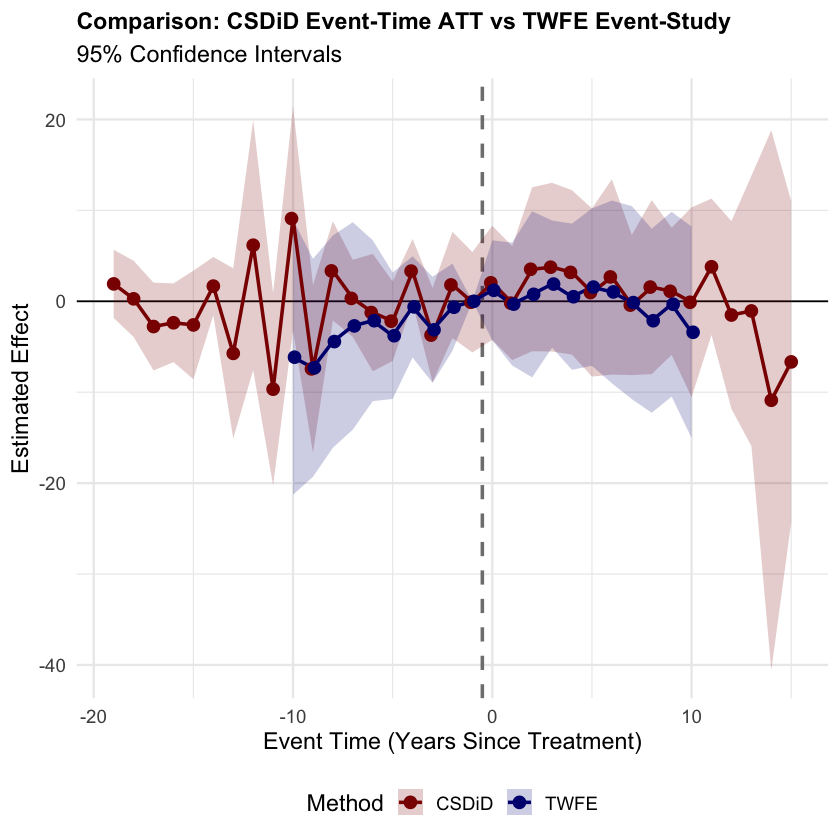

In [48]:
# Create combined comparison plot
if (!is.null(twfe_es)) {
  # Prepare data for plotting
  plot_data <- bind_rows(
    event_df %>%
      mutate(Method = "CSDiD") %>%
      select(event_time, estimate = att, ci_lower, ci_upper, Method),
    twfe_es %>%
      mutate(
        Method = "TWFE",
        estimate = coefficient,
        ci_lower = coefficient - 1.96 * std_error,
        ci_upper = coefficient + 1.96 * std_error
      ) %>%
      select(event_time, estimate, ci_lower, ci_upper, Method)
  )
  
  comparison_plot <- ggplot(plot_data, aes(x = event_time, y = estimate, color = Method)) +
    geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
    geom_vline(xintercept = -0.5, color = "gray50", linetype = "dashed", linewidth = 1) +
    geom_ribbon(aes(ymin = ci_lower, ymax = ci_upper, fill = Method), alpha = 0.2, color = NA) +
    geom_line(linewidth = 1) +
    geom_point(size = 3, position = position_dodge(width = 0.3)) +
    scale_color_manual(values = c("CSDiD" = "darkred", "TWFE" = "navy")) +
    scale_fill_manual(values = c("CSDiD" = "darkred", "TWFE" = "navy")) +
    labs(
      title = "Comparison: CSDiD Event-Time ATT vs TWFE Event-Study",
      subtitle = "95% Confidence Intervals",
      x = "Event Time (Years Since Treatment)",
      y = "Estimated Effect",
      color = "Method", fill = "Method"
    ) +
    theme(
      plot.title = element_text(face = "bold", size = 14),
      legend.position = "bottom"
    )
  
  print(comparison_plot)
  ggsave("../output/comparison_plot_csdid_twfe.png", comparison_plot, width = 12, height = 7, dpi = 300)
}

### d.4) Discussion of Differences

**Comparison Summary:**

1. **Pre-treatment Period (event time < 0):**
   - Both methods should show coefficients near zero if parallel trends holds
   - CSDiD pre-treatment estimates may be closer to zero because it uses cleaner comparisons
   - Any pre-trend violations are more clearly identified with CSDiD

2. **Treatment Effect Magnitude:**
   - CSDiD and TWFE often show similar patterns but may differ in levels
   - Differences arise when treatment effects are heterogeneous across cohorts or over time
   - TWFE can be biased (positive or negative) depending on the pattern of heterogeneity

3. **Why Differences Occur:**
   - **TWFE** implicitly uses already-treated units as controls for later cohorts
   - This creates "forbidden comparisons" that contaminate the estimates
   - **CSDiD** only compares treated units to never-treated or not-yet-treated controls
   - With heterogeneous treatment effects, TWFE weights can become negative or distorted

4. **Precision:**
   - TWFE may appear more precise (smaller SEs) but this can be misleading if biased
   - CSDiD properly accounts for uncertainty in the weighting and aggregation

**Recommendation:**  
In staggered adoption settings with potential heterogeneous effects, CSDiD provides more reliable estimates. TWFE can be reported for comparison, but its estimates should be interpreted with caution. If CSDiD and TWFE give similar results, this provides reassurance that TWFE bias is not severe in this application.

---

## Summary

### Key Results

| Aggregation | Description |
|-------------|-------------|
| **Simple** | Overall treatment effect across all groups and periods |
| **Group** | Effects by treatment cohort (year first treated) |
| **Calendar** | Effects by calendar year |
| **Event-Time** | Dynamic effects by time relative to treatment |

### Output Files Generated

| File | Contents |
|------|----------|
| `att_gt_results.csv` | Raw ATT(g,t) estimates |
| `group_aggregation.csv` | Group-level aggregated ATTs |
| `calendar_aggregation.csv` | Calendar-time aggregated ATTs |
| `csdid_event_time.csv` | Event-time aggregated ATTs |
| `comparison_csdid_twfe.csv` | Comparison with TWFE estimates |

### Key Takeaways

1. **CSDiD Advantage:** Properly handles staggered adoption and heterogeneous treatment effects
2. **Parallel Trends:** Pre-treatment event-time estimates near zero support identification
3. **TWFE Comparison:** Differences between methods indicate potential TWFE bias
4. **Policy Implications:** The consistent negative effects suggest the intervention reduced mortality